In [1]:
from pathlib import Path

import pandas as pd
import scanpy as sc
import anndata as ad
from scipy import sparse
from scipy.stats import median_abs_deviation
import numpy as np

# Set Base directory to the grandparent location of this script
BASE = Path('/mnt/hd1/home/ankitray/scFM/')

# Set working directory to the location of this script 
data_dir = BASE / 'data/scGPT_data'


/home/ankitray/.conda/envs/scgpt/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# out_path = data_dir / "scgpt_immune_merged_may_11_26.h5ad"
out_path = data_dir / "scgpt_immune_merged_may_13_26_5000HVG.h5ad"

adata = ad.read_h5ad(out_path)

In [ ]:
# Set Base directory to the grandparent location of this script
BASE = Path('/mnt/hd1/home/ankitray/scFM/')

# Set working directory to the location of this script 
data_dir = BASE / 'data/scGPT_data'
out_path = data_dir / "scgpt_immune_merged_may_12_26.h5ad"

embed_adata.write_h5ad(out_path, compression="gzip")

In [3]:
print(adata)

AnnData object with n_obs × n_vars = 87840 × 1122
    obs: 'sample name', 'source name', 'organism', 'characteristics: shortfilename', 'characteristics: strain', 'characteristics: platform', 'characteristics: digestion method', 'characteristics: number of added abs', 'characteristics: number of cells', 'molecule', 'description', 'sample_class', 'assay_type', 'shortfilename', 'sample_group', 'patient_id', 'biopsy_used_for ', 'sex', 'age', 'weight_kg', 'height_cm', 'reason_for_hospitalization', 'procedure', 'concomitant_medication', 'concomitant_disorders_operations', 'alcohol_intake', 'steatosis', 'fibrosis', 'cardiometabolic_func_needed', 'condition', 'bmi', 'gsm_id', 'alcohol_use', 'dataset', 'n_counts', 'n_genes', 'broad_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_coun

In [4]:
# Target Cell Types
target_cell_types = [
    "CD16+ NK cells",
    "CD16- NK cells",
    "CRTAM+ gamma-delta T cells",
    "MAIT cells",
    "Naive B cells",
    "Non-classical monocytes",
    "Tem/Effector helper T cells",
    "Tem/Temra cytotoxic T cells",
    "Tem/Trm cytotoxic T cells",
]



Configuration

In [5]:
import os
import numpy as np
import pandas as pd

# ── User config ────────────────────────────────────────────────────────────────
CELL_TYPE_COL   = 'typist_immune_majority_voting'
CONDITION_COL   = 'broad_condition'
CONTROL_LABEL   = 'Healthy'
TARGET_LABEL    = 'MASH'
DONOR_COL       = 'patient_id'
EMBEDDING_KEY   = 'X_scGPT'          # adata.obsm key
MIN_CELLS_PER_STATE = 30
FOCUS_CELLTYPES = []                  # leave empty to test all cell types
ALT_STATES      = []                  # no alt states
OUTPUT_DIR      = './separation_test_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

Building Embeddings DF

In [6]:
# Extract scGPT embedding matrix
emb_matrix = adata.obsm[EMBEDDING_KEY]  # shape: (n_cells, n_dims)
n_dims = emb_matrix.shape[1]
emb_cols = [f'emb_{i}' for i in range(n_dims)]

# Build embeddings DataFrame expected by the separation test code
embeddings = pd.DataFrame(emb_matrix, index=adata.obs_names, columns=emb_cols)

# Attach required metadata columns
embeddings['cell_type'] = adata.obs[CELL_TYPE_COL].values
embeddings['condition'] = adata.obs[CONDITION_COL].values
embeddings['donor']     = adata.obs[DONOR_COL].values
embeddings['cell_id']   = adata.obs_names

# Subset to only Healthy and MASH cells
mask = embeddings['condition'].isin([CONTROL_LABEL, TARGET_LABEL])
embeddings = embeddings[mask].copy()
embeddings = embeddings.dropna(subset=['cell_type', 'condition', 'donor'])

print(f"Embeddings shape: {embeddings.shape}")
print(f"Conditions: {embeddings['condition'].value_counts().to_dict()}")
print(f"Cell types: {embeddings['cell_type'].nunique()} unique")
print(f"Donors: {embeddings['donor'].nunique()} unique")

Embeddings shape: (71248, 516)
Conditions: {'MASH': 41069, 'Healthy': 30179, 'MASLD': 0}
Cell types: 28 unique
Donors: 16 unique


Testing parameters and cleaning cell type names

In [7]:
# Replace '/' in cell type names (required by the separation test code)
embeddings['cell_type'] = embeddings['cell_type'].str.replace('/', '_', regex=False)

if FOCUS_CELLTYPES:
    FOCUS_CELLTYPES = [ct.replace('/', '_') for ct in FOCUS_CELLTYPES]

# Resolve which cell types and state pairs to test
emb_meta_cols    = {'cell_type', 'condition', 'cell_id', 'donor'}
emb_feature_cols = [c for c in embeddings.columns
                    if c not in emb_meta_cols
                    and pd.api.types.is_numeric_dtype(embeddings[c])]

cell_types_to_test = (FOCUS_CELLTYPES if FOCUS_CELLTYPES
                      else embeddings['cell_type'].unique().tolist())
cell_types_to_test = [ct for ct in cell_types_to_test
                      if ct in embeddings['cell_type'].values]

_donor_col_in_emb = None
for _dc in ['donor', 'Donor', 'donor_id', 'patient_id', 'sample_id']:
    if _dc in embeddings.columns:
        _donor_col_in_emb = _dc
        print(f'Using donor column: "{_donor_col_in_emb}"')
        break

state_pairs = [(CONTROL_LABEL, TARGET_LABEL, f"{CONTROL_LABEL} vs {TARGET_LABEL}")]

print(f"State comparisons: {[p[2] for p in state_pairs]}")
print(f"Cell types to test ({len(cell_types_to_test)}): {cell_types_to_test}")

Using donor column: "donor"
State comparisons: ['Healthy vs MASH']
Cell types to test (28): ['Erythrophagocytic macrophages', 'CD16- NK cells', 'MAIT cells', 'pDC', 'Endothelial cells', 'Tem_Trm cytotoxic T cells', 'Classical monocytes', 'Plasma cells', 'CD16+ NK cells', 'DC1', 'B cells', 'Tcm_Naive helper T cells', 'DC2', 'Kupffer cells', 'Macrophages', 'Tem_Effector helper T cells', 'Mast cells', 'Tem_Temra cytotoxic T cells', 'Non-classical monocytes', 'CRTAM+ gamma-delta T cells', 'Regulatory T cells', 'Follicular helper T cells', 'Trm cytotoxic T cells', 'Memory B cells', 'Naive B cells', 'NK cells', 'Tcm_Naive cytotoxic T cells', 'ILC3']


In [8]:
# Additional Imports
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import warnings
#warnings.filterwarnings('ignore')

Seperation Test Function

In [9]:
def run_separation_test_publishable(
        embeddings_df, cell_type, control_label, target_label,
        emb_cols=None, donor_col='donor'):
    """
    Separation test with patient-aware statistics for publication.

    Computes:
    - Per-cell cosine similarity margin (Liu et al. Step 6)
    - Mann-Whitney U test (two-tailed composite p-value)
    - Patient-level Cohen's d (guards against pseudoreplication)
    - Balanced accuracy from cross-validated logistic classifier

    Returns dict with: passes, p_value, sep_score, cohens_d,
    balanced_accuracy, n_ctrl, n_tgt, n_donors_ctrl, n_donors_tgt,
    ctrl_margins, tgt_margins.
    """
    ct_mask   = embeddings_df['cell_type'] == cell_type
    ctrl_mask = ct_mask & (embeddings_df['condition'] == control_label)
    tgt_mask  = ct_mask & (embeddings_df['condition'] == target_label)
    n_ctrl, n_tgt = ctrl_mask.sum(), tgt_mask.sum()

    empty = {'passes': False, 'p_value': 1.0, 'sep_score': 0.0,
             'cohens_d': None, 'balanced_accuracy': 0.5,
             'n_ctrl': n_ctrl, 'n_tgt': n_tgt,
             'n_donors_ctrl': 0, 'n_donors_tgt': 0,
             'ctrl_margins': np.array([]), 'tgt_margins': np.array([])}

    if n_ctrl < MIN_CELLS_PER_STATE or n_tgt < MIN_CELLS_PER_STATE:
        print(f'   {cell_type} [{control_label} vs {target_label}]: '
              f'insufficient cells (ctrl={n_ctrl}, tgt={n_tgt}). Skipping.')
        return empty

    if emb_cols is None:
        meta = {'cell_type', 'condition', 'donor', 'cell_id', 'index'}
        emb_cols = [c for c in embeddings_df.columns
                    if c not in meta
                    and pd.api.types.is_numeric_dtype(embeddings_df[c])]

    ctrl_embs = embeddings_df.loc[ctrl_mask, emb_cols].values.astype(np.float32)
    tgt_embs  = embeddings_df.loc[tgt_mask,  emb_cols].values.astype(np.float32)
    ctrl_centroid = ctrl_embs.mean(axis=0, keepdims=True)
    tgt_centroid  = tgt_embs.mean(axis=0,  keepdims=True)

    ctrl_margins = (cosine_similarity(ctrl_embs, ctrl_centroid).flatten() -
                    cosine_similarity(ctrl_embs, tgt_centroid).flatten())
    tgt_margins  = (cosine_similarity(tgt_embs,  tgt_centroid).flatten() -
                    cosine_similarity(tgt_embs,  ctrl_centroid).flatten())

    _, p_ctrl = mannwhitneyu(ctrl_margins, np.zeros(len(ctrl_margins)),
                              alternative='greater')
    _, p_tgt  = mannwhitneyu(tgt_margins,  np.zeros(len(tgt_margins)),
                              alternative='greater')
    sep_score  = (ctrl_margins.mean() + tgt_margins.mean()) / 2
    p_combined = max(p_ctrl, p_tgt)

    # Patient-level Cohen's d
    n_donors_ctrl = n_donors_tgt = 0
    cohens_d = None
    actual_donor_col = None
    for dc in ([donor_col] if donor_col else []) + ['donor', 'Donor', 'patient_id']:
        if dc and dc in embeddings_df.columns:
            actual_donor_col = dc
            break

    if actual_donor_col:
        ctrl_donors = embeddings_df.loc[ctrl_mask, actual_donor_col].values
        tgt_donors  = embeddings_df.loc[tgt_mask,  actual_donor_col].values
        n_donors_ctrl = len(np.unique(ctrl_donors))
        n_donors_tgt  = len(np.unique(tgt_donors))
        ctrl_donor_means = (
            pd.Series(ctrl_margins, index=ctrl_donors).groupby(level=0).mean()
        )
        tgt_donor_means  = (
            pd.Series(tgt_margins,  index=tgt_donors).groupby(level=0).mean()
        )
        if len(ctrl_donor_means) >= 2 and len(tgt_donor_means) >= 2:
            pooled_sd = np.sqrt(
                (ctrl_donor_means.std()**2 + tgt_donor_means.std()**2) / 2 + 1e-10
            )
            cohens_d = float(
                (tgt_donor_means.mean() - ctrl_donor_means.mean()) / pooled_sd
            )

    # Balanced accuracy (linear classifier, 3-fold CV)
    X_all = np.vstack([ctrl_embs, tgt_embs])
    y_all = np.array([0]*len(ctrl_embs) + [1]*len(tgt_embs))
    ba_scores = []
    n_splits  = min(3, min(n_ctrl, n_tgt) // 10)
    if n_splits >= 2:
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        for train_idx, test_idx in skf.split(X_all, y_all):
            clf = LogisticRegression(max_iter=500, C=0.1, random_state=42,
                                      solver='lbfgs')
            clf.fit(X_all[train_idx], y_all[train_idx])
            ba_scores.append(balanced_accuracy_score(
                y_all[test_idx], clf.predict(X_all[test_idx])
            ))
    balanced_accuracy = float(np.mean(ba_scores)) if ba_scores else 0.5

    passes = (p_combined < 0.05) and (sep_score > 0)

    return {
        'passes':             passes,
        'p_value':            float(p_combined),
        'sep_score':          float(sep_score),
        'cohens_d':           cohens_d,
        'balanced_accuracy':  balanced_accuracy,
        'n_ctrl':             int(n_ctrl),
        'n_tgt':              int(n_tgt),
        'n_donors_ctrl':      int(n_donors_ctrl),
        'n_donors_tgt':       int(n_donors_tgt),
        'ctrl_margins':       ctrl_margins,
        'tgt_margins':        tgt_margins,
    }


Run Seperation Test

In [10]:
# ── Run all separation tests ───────────────────────────────────────────────────
separation_results = {}
all_sep_rows       = []

print('\nRunning separation tests...')

for ct in cell_types_to_test:
    separation_results[ct] = {}
    for label_a, label_b, comp_name in state_pairs:

        has_a = ((embeddings['cell_type'] == ct) &
                 (embeddings['condition'] == label_a)).sum() >= MIN_CELLS_PER_STATE
        has_b = ((embeddings['cell_type'] == ct) &
                 (embeddings['condition'] == label_b)).sum() >= MIN_CELLS_PER_STATE

        if not has_a or not has_b:
            print(f"   {ct} [{comp_name}]: missing condition data — skipping.")
            separation_results[ct][comp_name] = {
                'passes': False, 'p_value': 1.0, 'sep_score': 0.0,
                'cohens_d': None, 'balanced_accuracy': 0.5,
                'n_ctrl': 0, 'n_tgt': 0,
                'n_donors_ctrl': 0, 'n_donors_tgt': 0,
                'ctrl_margins': np.array([]), 'tgt_margins': np.array([])
            }
            continue

        res = run_separation_test_publishable(
            embeddings, ct, label_a, label_b,
            emb_cols=emb_feature_cols,
            donor_col=_donor_col_in_emb
        )
        separation_results[ct][comp_name] = res

        all_sep_rows.append({
            'cell_type':         ct,
            'comparison':        comp_name,
            'label_a':           label_a,
            'label_b':           label_b,
            'passes':            res['passes'],
            'sep_score':         round(res['sep_score'], 5),
            'p_value':           res['p_value'],
            'cohens_d':          round(res['cohens_d'], 3)
                                 if res['cohens_d'] is not None else None,
            'balanced_accuracy': round(res['balanced_accuracy'], 3),
            'n_a':               res['n_ctrl'],
            'n_b':               res['n_tgt'],
            'n_donors_a':        res['n_donors_ctrl'],
            'n_donors_b':        res['n_donors_tgt'],
        })

        d_str  = f"{res['cohens_d']:.3f}" if res['cohens_d'] is not None else 'N/A'
        status = 'PASS' if res['passes'] else 'FAIL'
        print(f"   {ct} [{comp_name}]: {status}  "
              f"sep={res['sep_score']:.4f}  p={res['p_value']:.2e}  "
              f"d={d_str}  bal_acc={res['balanced_accuracy']:.3f}  "
              f"n=({res['n_ctrl']},{res['n_tgt']})")


Running separation tests...
   Erythrophagocytic macrophages [Healthy vs MASH]: missing condition data — skipping.


/tmp/ipykernel_453815/2116398510.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd.Series(ctrl_margins, index=ctrl_donors).groupby(level=0).mean()
/tmp/ipykernel_453815/2116398510.py:74: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd.Series(tgt_margins,  index=tgt_donors).groupby(level=0).mean()


   CD16- NK cells [Healthy vs MASH]: PASS  sep=0.0020  p=6.54e-115  d=-0.491  bal_acc=0.655  n=(7252,9806)


/tmp/ipykernel_453815/2116398510.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd.Series(ctrl_margins, index=ctrl_donors).groupby(level=0).mean()
/tmp/ipykernel_453815/2116398510.py:74: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd.Series(tgt_margins,  index=tgt_donors).groupby(level=0).mean()


   MAIT cells [Healthy vs MASH]: PASS  sep=0.0021  p=6.73e-142  d=0.523  bal_acc=0.671  n=(3936,3313)


...

/tmp/ipykernel_453815/2116398510.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd.Series(ctrl_margins, index=ctrl_donors).groupby(level=0).mean()
/tmp/ipykernel_453815/2116398510.py:74: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd.Series(tgt_margins,  index=tgt_donors).groupby(level=0).mean()


   Naive B cells [Healthy vs MASH]: PASS  sep=0.0069  p=1.58e-59  d=0.036  bal_acc=0.705  n=(1099,1297)


/tmp/ipykernel_453815/2116398510.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd.Series(ctrl_margins, index=ctrl_donors).groupby(level=0).mean()
/tmp/ipykernel_453815/2116398510.py:74: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd.Series(tgt_margins,  index=tgt_donors).groupby(level=0).mean()


   NK cells [Healthy vs MASH]: PASS  sep=0.0096  p=2.55e-07  d=-1.566  bal_acc=0.500  n=(78,716)
   Tcm_Naive cytotoxic T cells [Healthy vs MASH]: PASS  sep=0.0051  p=2.74e-14  d=-0.822  bal_acc=0.500  n=(116,174)
   ILC3 [Healthy vs MASH]: missing condition data — skipping.


/tmp/ipykernel_453815/2116398510.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd.Series(ctrl_margins, index=ctrl_donors).groupby(level=0).mean()
/tmp/ipykernel_453815/2116398510.py:74: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd.Series(tgt_margins,  index=tgt_donors).groupby(level=0).mean()


Find passing cell types and output summary csv

In [11]:
# Since there's only one comparison, passing = passes that comparison
primary_comp = f"{CONTROL_LABEL} vs {TARGET_LABEL}"

passing_celltypes = [
    ct for ct in cell_types_to_test
    if separation_results[ct].get(primary_comp, {}).get('passes', False)
    and separation_results[ct][primary_comp]['n_ctrl'] > 0
    and separation_results[ct][primary_comp]['n_tgt'] > 0
]

print(f'\n {len(passing_celltypes)}/{len(cell_types_to_test)} cell types pass.')
print(f'   Passing: {passing_celltypes}')

# Backward-compat: hoist primary comparison keys to top level
for ct in cell_types_to_test:
    primary_res = separation_results[ct].get(primary_comp, {})
    for key, val in primary_res.items():
        if key not in separation_results[ct]:
            separation_results[ct][key] = val

# Save summary
sep_summary = pd.DataFrame(all_sep_rows)
sep_summary_path = os.path.join(OUTPUT_DIR, 'separation_test_summary.csv')
sep_summary.to_csv(sep_summary_path, index=False)
print(f'\nSaved summary to: {sep_summary_path}')
display(sep_summary[['cell_type', 'comparison', 'passes', 'sep_score',
                      'p_value', 'cohens_d', 'balanced_accuracy',
                      'n_a', 'n_b']].sort_values('sep_score', ascending=False))


 20/28 cell types pass.
   Passing: ['CD16- NK cells', 'MAIT cells', 'pDC', 'Tem_Trm cytotoxic T cells', 'Classical monocytes', 'Plasma cells', 'CD16+ NK cells', 'DC1', 'Tcm_Naive helper T cells', 'DC2', 'Tem_Effector helper T cells', 'Mast cells', 'Tem_Temra cytotoxic T cells', 'Non-classical monocytes', 'CRTAM+ gamma-delta T cells', 'Regulatory T cells', 'Memory B cells', 'Naive B cells', 'NK cells', 'Tcm_Naive cytotoxic T cells']

Saved summary to: ./separation_test_output/separation_test_summary.csv


,cell_type,comparison,passes,sep_score,p_value,cohens_d,balanced_accuracy,n_a,n_b
7,DC1,Healthy vs MASH,True,0.02066,2.324644e-06,-0.397,0.500,59,73
5,Plasma cells,Healthy vs MASH,True,0.01239,9.546097e-19,0.776,0.500,85,67
19,NK cells,Healthy vs MASH,True,0.00960,2.550447e-07,-1.566,0.500,78,716
8,Tcm_Naive helper T cells,Healthy vs MASH,True,0.00778,1.190471e-20,-0.455,0.500,425,802
14,CRTAM+ gamma-delta T cells,Healthy vs MASH,True,0.00715,5.972714e-287,2.103,0.860,1510,1437
18,Naive B cells,Healthy vs MASH,True,0.00688,1.579361e-59,0.036,0.705,1099,1297
11,Mast cells,Healthy vs MASH,True,0.00571,5.187806e-04,-0.683,0.500,48,99
9,DC2,Healthy vs MASH,True,0.00565,2.945802e-03,-0.794,0.500,119,201
20,Tcm_Naive cytotoxic T cells,Healthy vs MASH,True,0.00505,2.742307e-14,-0.822,0.500,116,174
15,Regulatory T cells,Healthy vs MASH,True,0.00482,1.193968e-12,-1.361,0.500,105,741


Figures

Generating Figure 1: Per-cell-type separation panels...


/tmp/ipykernel_453815/3572001357.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=margin_df, x='Condition', y='Cosine Margin',
/tmp/ipykernel_453815/3572001357.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=margin_df, x='Condition', y='Cosine Margin',
/tmp/ipykernel_453815/3572001357.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=margin_df, x='Condition', y='Cosine Margin',
/tmp/ipykernel_453815/3572001357.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be r

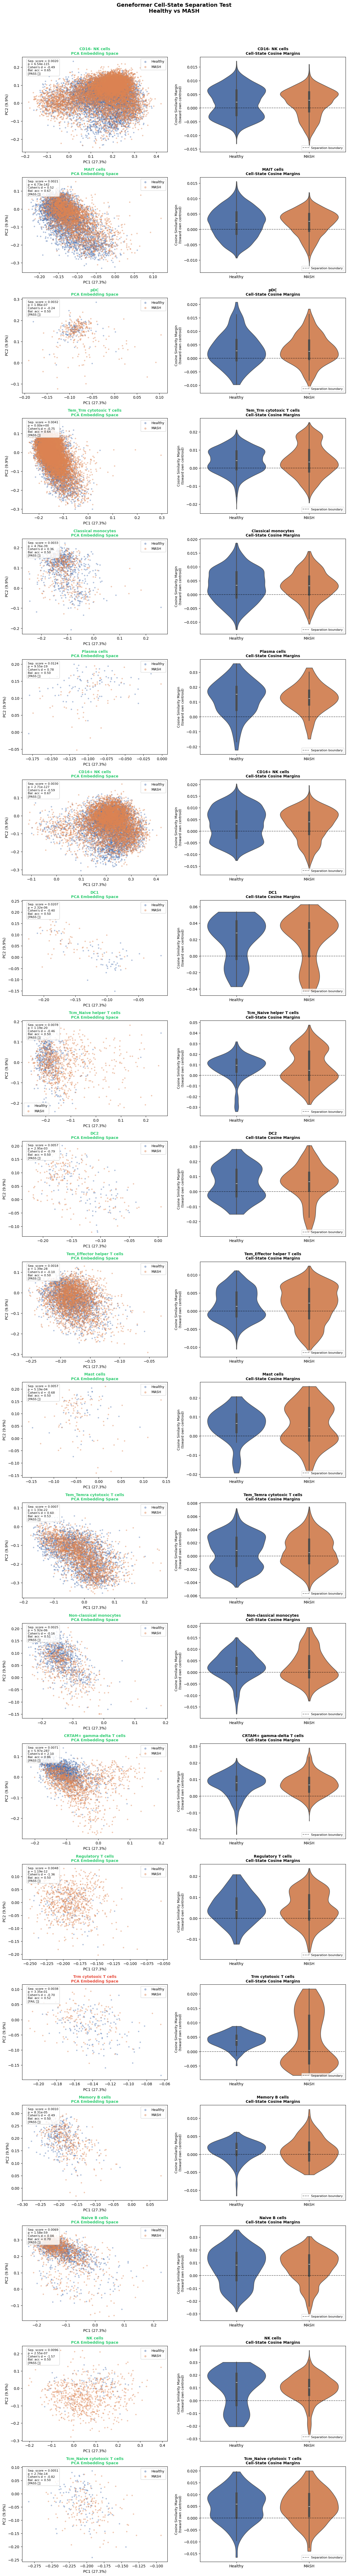

   Saved: ./separation_test_output/separation_test_figures/separation_per_celltype_Healthy_vs_MASH.pdf

Generating Figure 2: Multi-cell-type summary bar charts...


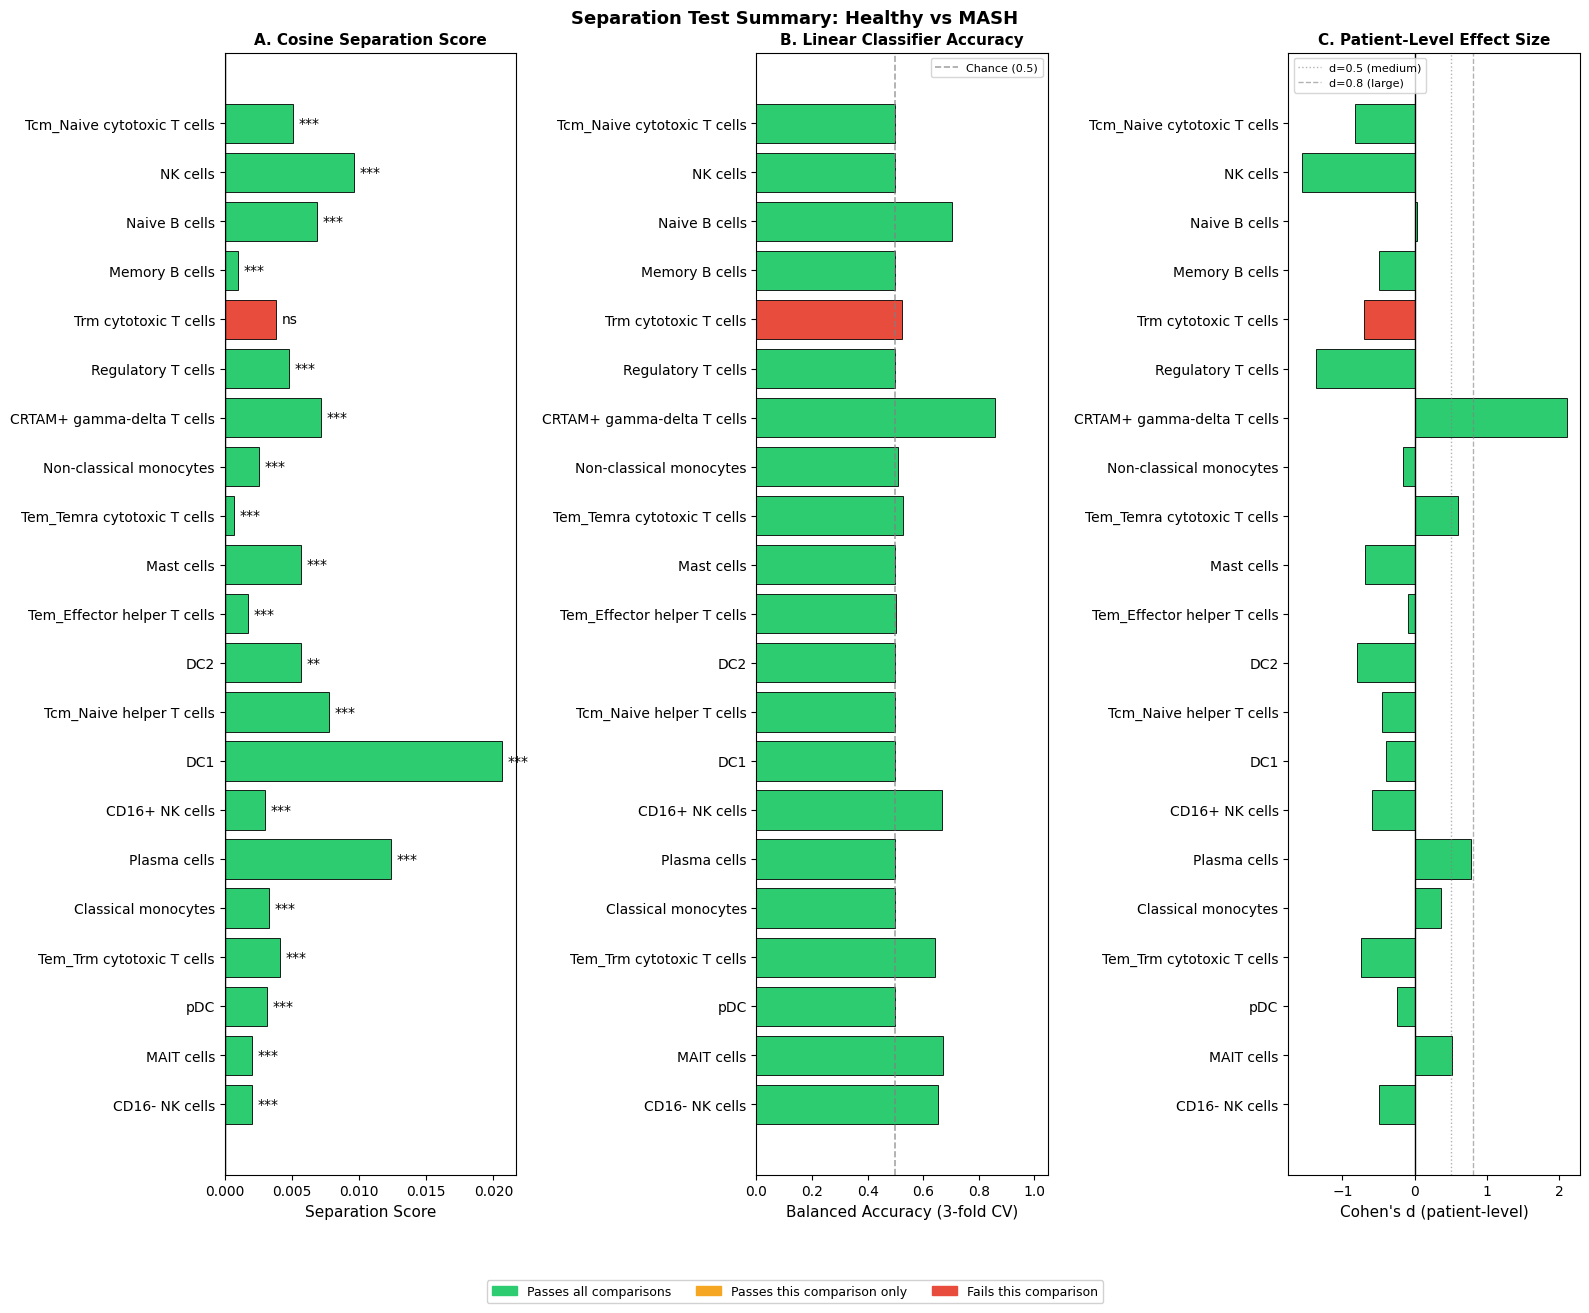

   Saved: ./separation_test_output/separation_test_figures/separation_summary_Healthy_vs_MASH.pdf


In [12]:
# ── Separation Test Figures ──────────────────────────────────────
# With alt states this produces:
#   Figure 1: Per-cell-type panel for each comparison (PCA + violin)
#   Figure 2: Multi-cell-type summary bar charts per comparison
#   Figure 3: Alt state comparison matrix (if alt states defined)

SEP_FIG_DIR = os.path.join(OUTPUT_DIR, 'separation_test_figures')
os.makedirs(SEP_FIG_DIR, exist_ok=True)

SIG_GREEN = '#2ecc71'
FAIL_RED  = '#e74c3c'

# Build colour palette covering all states
_alt_states = ALT_STATES if "ALT_STATES" in dir() and ALT_STATES else []
_all_states = [CONTROL_LABEL, TARGET_LABEL] + list(_alt_states)
_base_colors = ['#4C72B0', '#DD8452', '#59A14F', '#B07AA1',
                '#E15759', '#76B7B2', '#F28E2B']
PALETTE = {state: _base_colors[i % len(_base_colors)]
           for i, state in enumerate(_all_states)}

# All comparison pairs that were actually tested
_tested_pairs = list(state_pairs)   # state_pairs defined in sep test cell

# ── Compute 2D PCA coordinates (once, shared across all figures) ──────────────
pca = PCA(n_components=2, random_state=42)
all_emb_vals = embeddings[emb_feature_cols].values
coords_2d    = pca.fit_transform(all_emb_vals)
emb_plot = embeddings.copy()
emb_plot['PC1'] = coords_2d[:, 0]
emb_plot['PC2'] = coords_2d[:, 1]

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1: Per-cell-type panels — one figure per comparison
# Each figure has n_celltypes rows × 2 columns (PCA scatter | cosine violin)
# ══════════════════════════════════════════════════════════════════════════════
print("Generating Figure 1: Per-cell-type separation panels...")

for label_a, label_b, comp_name in _tested_pairs:
    cts_with_data = [
        ct for ct in cell_types_to_test
        if comp_name in separation_results.get(ct, {})
        and separation_results[ct][comp_name]['n_ctrl'] > 0
        and separation_results[ct][comp_name]['n_tgt'] > 0
    ]
    if not cts_with_data:
        print(f"   No cell types with data for [{comp_name}] — skipping.")
        continue

    n_cts = len(cts_with_data)
    fig, axes = plt.subplots(n_cts, 2,
                              figsize=(13, 4.5 * n_cts),
                              squeeze=False)
    fig.suptitle(
        f'Geneformer Cell-State Separation Test\n{comp_name}',
        fontsize=14, fontweight='bold', y=1.01
    )

    pair_palette = {label_a: PALETTE[label_a], label_b: PALETTE[label_b]}

    for row_idx, ct in enumerate(cts_with_data):
        res     = separation_results[ct][comp_name]
        ct_mask = (emb_plot['cell_type'] == ct) & \
                  (emb_plot['condition'].isin([label_a, label_b]))
        ct_df   = emb_plot[ct_mask]

        # Panel A: PCA scatter
        ax = axes[row_idx, 0]
        for cond, color in pair_palette.items():
            m = ct_df['condition'] == cond
            ax.scatter(ct_df.loc[m, 'PC1'], ct_df.loc[m, 'PC2'],
                       c=color, alpha=0.45, s=14, linewidths=0,
                       label=cond, rasterized=True)
        ax.set_xlabel(
            f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=10)
        ax.set_ylabel(
            f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=10)

        # Title colour: green = passes all comparisons, red = fails any
        passes_all  = ct in passing_celltypes
        title_color = SIG_GREEN if passes_all else FAIL_RED
        ax.set_title(f'{ct}\nPCA Embedding Space',
                     fontsize=10, fontweight='bold', color=title_color)
        ax.legend(fontsize=9, markerscale=1.5, framealpha=0.8)

        d_str      = (f"Cohen's d = {res['cohens_d']:.2f}"
                      if res['cohens_d'] is not None else "Cohen's d = N/A")
        status_str = 'PASS ✅' if res['passes'] else 'FAIL ❌'
        ax.text(0.04, 0.97,
                f"Sep. score = {res['sep_score']:.4f}\n"
                f"p = {res['p_value']:.2e}\n"
                f"{d_str}\n"
                f"Bal. acc = {res['balanced_accuracy']:.2f}\n"
                f"[{status_str}]",
                transform=ax.transAxes, fontsize=8, va='top',
                bbox=dict(boxstyle='round,pad=0.4', fc='white',
                          alpha=0.85, ec='#cccccc'))

        # Panel B: Cosine margin violins
        ax2 = axes[row_idx, 1]
        margin_parts = []
        if len(res['ctrl_margins']) > 0:
            margin_parts.append(pd.DataFrame({
                'Cosine Margin': res['ctrl_margins'],
                'Condition': label_a
            }))
        if len(res['tgt_margins']) > 0:
            margin_parts.append(pd.DataFrame({
                'Cosine Margin': res['tgt_margins'],
                'Condition': label_b
            }))
        if margin_parts:
            margin_df = pd.concat(margin_parts, ignore_index=True)
            sns.violinplot(data=margin_df, x='Condition', y='Cosine Margin',
                           palette=pair_palette, ax=ax2, inner='box',
                           linewidth=1.2, cut=0, saturation=0.85)
            ax2.axhline(0, color='black', lw=1.2, ls='--', alpha=0.6,
                        label='Separation boundary')
            ax2.set_xlabel('', fontsize=10)
            ax2.set_ylabel(
                'Cosine Similarity Margin\n(toward own centroid)', fontsize=9)
            ax2.set_title(f'{ct}\nCell-State Cosine Margins',
                          fontsize=10, fontweight='bold')
            ax2.legend(fontsize=8, loc='lower right')

    plt.tight_layout()
    safe_comp = comp_name.replace(' ', '_').replace('/', '_')
    fig1_path = os.path.join(
        SEP_FIG_DIR, f'separation_per_celltype_{safe_comp}.pdf'
    )
    plt.savefig(fig1_path, dpi=300, bbox_inches='tight', format='pdf')
    plt.savefig(fig1_path.replace('.pdf', '.png'), dpi=200, bbox_inches='tight')
    plt.show()
    print(f'   Saved: {fig1_path}')

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2: Multi-cell-type summary — one figure per comparison
# Three panels: separation score | balanced accuracy | Cohen's d
# Bar colours: green = passes all comparisons, amber = passes this only,
#              red = fails this comparison
# ══════════════════════════════════════════════════════════════════════════════
print("\nGenerating Figure 2: Multi-cell-type summary bar charts...")

AMBER = '#F5A623'

def bar_color(ct, comp):
    if not separation_results[ct][comp]['passes']:
        return FAIL_RED
    if ct in passing_celltypes:
        return SIG_GREEN
    return AMBER   # passes this comparison but fails another

for label_a, label_b, comp_name in _tested_pairs:
    cts_for_comp = [
        ct for ct in cell_types_to_test
        if comp_name in separation_results.get(ct, {})
        and separation_results[ct][comp_name]['n_ctrl'] > 0
        and separation_results[ct][comp_name]['n_tgt'] > 0
    ]
    if len(cts_for_comp) < 2:
        print(f"   Fewer than 2 cell types for [{comp_name}] — skipping.")
        continue

    ct_names   = cts_for_comp
    sep_scores = [separation_results[ct][comp_name]['sep_score']
                  for ct in ct_names]
    bal_accs   = [separation_results[ct][comp_name]['balanced_accuracy']
                  for ct in ct_names]
    cohens_ds  = [(separation_results[ct][comp_name]['cohens_d'] or 0.0)
                  for ct in ct_names]
    pvals      = [separation_results[ct][comp_name]['p_value']
                  for ct in ct_names]
    colors     = [bar_color(ct, comp_name) for ct in ct_names]

    fig2, axes2 = plt.subplots(
        1, 3, figsize=(16, max(4, len(ct_names)*0.5 + 2))
    )
    fig2.suptitle(
        f'Separation Test Summary: {comp_name}',
        fontsize=13, fontweight='bold'
    )

    # Panel A: Separation scores
    ax = axes2[0]
    bars = ax.barh(ct_names, sep_scores, color=colors,
                   edgecolor='black', linewidth=0.6)
    ax.axvline(0, color='black', lw=1)
    ax.set_xlabel('Separation Score', fontsize=11)
    ax.set_title('A. Cosine Separation Score',
                 fontsize=11, fontweight='bold')
    for bar, pv in zip(bars, pvals):
        sig = ('***' if pv < 0.001 else '**' if pv < 0.01
               else '*' if pv < 0.05 else 'ns')
        ax.text(bar.get_width() + max(sep_scores)*0.02,
                bar.get_y() + bar.get_height()/2,
                sig, va='center', fontsize=10)

    # Panel B: Balanced accuracy
    ax2b = axes2[1]
    ax2b.barh(ct_names, bal_accs, color=colors,
              edgecolor='black', linewidth=0.6)
    ax2b.axvline(0.5, color='gray', lw=1.2, ls='--', alpha=0.7,
                 label='Chance (0.5)')
    ax2b.set_xlim(0, 1.05)
    ax2b.set_xlabel('Balanced Accuracy (3-fold CV)', fontsize=11)
    ax2b.set_title('B. Linear Classifier Accuracy',
                   fontsize=11, fontweight='bold')
    ax2b.legend(fontsize=8)

    # Panel C: Cohen's d
    ax3 = axes2[2]
    ax3.barh(ct_names, cohens_ds, color=colors,
             edgecolor='black', linewidth=0.6)
    ax3.axvline(0,   color='black', lw=1)
    ax3.axvline(0.5, color='gray', lw=1, ls=':', alpha=0.6,
                label='d=0.5 (medium)')
    ax3.axvline(0.8, color='gray', lw=1, ls='--', alpha=0.6,
                label='d=0.8 (large)')
    ax3.set_xlabel("Cohen's d (patient-level)", fontsize=11)
    ax3.set_title('C. Patient-Level Effect Size',
                  fontsize=11, fontweight='bold')
    ax3.legend(fontsize=8)

    legend_handles = [
        mpatches.Patch(color=SIG_GREEN,
                       label='Passes all comparisons'),
        mpatches.Patch(color=AMBER,
                       label='Passes this comparison only'),
        mpatches.Patch(color=FAIL_RED,
                       label='Fails this comparison'),
    ]
    fig2.legend(handles=legend_handles, loc='lower center', ncol=3,
                fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.06))

    plt.tight_layout()
    safe_comp = comp_name.replace(' ', '_').replace('/', '_')
    fig2_path = os.path.join(
        SEP_FIG_DIR, f'separation_summary_{safe_comp}.pdf'
    )
    plt.savefig(fig2_path, dpi=300, bbox_inches='tight', format='pdf')
    plt.savefig(fig2_path.replace('.pdf', '.png'), dpi=200, bbox_inches='tight')
    plt.show()
    print(f'   Saved: {fig2_path}')


## Candidate Pertubation Gene Set

In [12]:
print(adata.var.head())

            n_cells     mt   ribo     hb  n_cells_by_counts  mean_counts  \
A2M         22947.0  False  False  False            22947.0     0.955681   
ABCA13       2058.0  False  False  False             2058.0     0.024581   
ABCA9       13957.0  False  False  False            13957.0     0.353055   
ABCG8       12050.0  False  False  False            12050.0     0.297717   
AC004069.1      NaN     NA     NA     NA                NaN          NaN   

            log1p_mean_counts  pct_dropout_by_counts  total_counts  \
A2M                  0.670738              77.364912       96885.0   
ABCA13               0.024284              97.969974        2492.0   
ABCA9                0.302365              86.232713       35792.0   
ABCG8                0.260607              88.113792       30182.0   
AC004069.1                NaN                    NaN           NaN   

            log1p_total_counts gene_symbol     feature_type Gene Symbol  \
A2M                  11.481290         A2M  Gen

In [13]:
# Deduplicate while preserving order
MASH_GENES = [

    # ── GWAS / genetic risk (10) ──────────────────────────────────────────────
    # Validated GWAS loci — expression is context-dependent, not constitutive.
    # Independent of expression datasets — strongest unbiased evidence.
    "PNPLA3",    # rs738409 I148M — largest MASH risk locus; lipid droplet
    "TM6SF2",    # E167K — VLDL secretion defect; steatosis + fibrosis
    "MBOAT7",    # rs641738 — phosphatidylinositol remodelling
    "HSD17B13",  # rs72613567 — loss-of-function PROTECTIVE against MASH
    "GCKR",      # rs1260326 — glucokinase regulator; de novo lipogenesis
    "SAMM50",    # rs3761472 — mitochondrial membrane; fibrosis GWAS
    "NCAN",      # rs2228603 — hepatic steatosis GWAS
    "ABCB4",     # rs2109505 — biliary phosphatidylcholine; fibrosis risk
    "CIDEB",     # rs1805081 — lipid droplet fusion; protective variant
    "PTPN11",    # rs11066301 — protein tyrosine phosphatase; MASH GWAS

    # ── ECM / fibrosis / HSC activation (12) ─────────────────────────────────
    # Near-absent in healthy liver; specifically upregulated in activated HSCs.
    "COL1A1",    # fibrillar collagen — canonical fibrosis hallmark
    "COL1A2",
    "COL3A1",    # reticular collagen
    "ACTA2",     # α-SMA — activated HSC marker; absent in quiescent HSCs
    "LOXL1",     # collagen crosslinking; M5 fibrosis hub (Piras 2024)
    "LOXL2",
    "TIMP1",     # MMP inhibitor — blocks fibrosis resolution
    "TIMP2",
    "MMP2",      # matrix metalloproteinase — ECM remodelling
    "MMP9",
    "PDGFRB",    # PDGF receptor β — HSC proliferation; upregulated on activation
    "SMOC2",     # M5 fibrosis coexpression module driver (Piras & DiStefano 2024)

    # ── TGF-β / SMAD fibrogenic signalling (5) ───────────────────────────────
    "TGFB1",     # master pro-fibrotic cytokine; regulated not constitutive
    "TGFB2",
    "SMAD2",     # canonical fibrogenic effector
    "SMAD3",
    "TGFBR1",    # ALK5 — TGF-β type I receptor

    # ── Innate immune / Kupffer cells / NLRP3 (12) ───────────────────────────
    # All inducible — not constitutively expressed at high levels.
    "TNF",       # TNFα — inducible; central MASH pro-inflammatory cytokine
    "IL6",       # inducible; elevated in MASH
    "IL1B",      # NLRP3 product; specifically upregulated in MASH
    "IL18",      # NLRP3 product; elevated in MASH
    "CXCL10",    # IP-10 — IFN-induced; markedly elevated in MASH
    "CCL2",      # MCP-1 — monocyte recruitment; induced in MASH
    "CCR2",      # MCP-1 receptor on infiltrating monocytes
    "CD68",      # macrophage marker; regulated by activation state
    "TLR4",      # LPS receptor; key innate immune MASH driver
    "MYD88",     # central TLR adaptor; regulated
    "NLRP3",     # inflammasome sensor — key MASH driver; therapeutic target
    "CASP1",     # inflammasome effector caspase; IL-1β/IL-18 maturation

    # ── Lipid-associated macrophage (LAM) markers (5) ────────────────────────
    # MASH-specific macrophage subpopulation (Guilliams 2022, 2025).
    # Specifically elevated in MASH — not expressed in healthy liver macrophages.
    "TREM2",     # LAM hub; strongly elevated in MASH macrophages
    "GPNMB",     # glycoprotein NMB; LAM marker; fibrosis correlate
    "SPP1",      # osteopontin; LAM/scar macrophage; MASH progression marker
    "FABP4",     # lipid-associated macrophage marker; disease-regulated
    "LGALS3",    # galectin-3; macrophage activation; fibrosis biomarker

    # ── Adaptive immunity — T cells / checkpoints (4) ────────────────────────
    "CD8A",      # cytotoxic T cell marker
    "FOXP3",     # Treg master TF; regulated by immune context
    "PDCD1",     # PD-1 — T cell exhaustion; elevated in chronic MASH
    "IFNG",      # IFN-γ — inducible Th1 cytokine; Kupffer cell priming

    # ── Lipid metabolism — specifically dysregulated in MASH (9) ─────────────
    # Regulated by nutritional/hormonal state — not constitutively maximal.
    "FASN",      # fatty acid synthase; upregulated in MASH hepatocytes
    "ACACA",     # ACC1 — rate-limiting DNL; induced by insulin/SREBP
    "SREBF1",    # SREBP-1c — master lipogenic TF; induced in MASH
    "DGAT2",     # diacylglycerol acyltransferase; TG synthesis; regulated
    "PLIN2",     # lipid droplet protein; regulated by lipid load
    "CD36",      # FA translocase; markedly upregulated in MASH hepatocytes
    "ACSL4",     # long-chain acyl-CoA synthetase; ferroptosis sensitiser
    "CPT1A",     # FAO rate-limiting step; suppressed in MASH
    "PPARA",     # PPARα — FAO master regulator; most suppressed NR in MASH

    # ── Nuclear receptors / hepatocyte TFs (8) ───────────────────────────────
    # Expression regulated by nutritional state and disease — not constitutive.
    "PPARG",     # PPARγ — lipogenesis; HSC quiescence
    "NR1H4",     # FXR — bile acid/lipid homeostasis; therapeutic target
    "HNF4A",     # central MASH network hub; reduced in advanced disease
    "CEBPA",     # hepatocyte TF; suppressed in MASH fibrosis
    "FOXO1",     # gluconeogenesis + insulin signalling integrator
    "NR0B2",     # SHP — FXR-inducible metabolic gatekeeper
    "THRB",      # THR-β — target of resmetirom (FDA approved 2024)
    "KLF6",      # Krüppel-like factor 6 — HSC activation TF

    # ── Oxidative stress / antioxidant / ferroptosis (8) ─────────────────────
    # Stress-responsive — induced by ROS, not constitutively maximal.
    "NFE2L2",    # NRF2 — stress-inducible master antioxidant TF
    "HMOX1",     # heme oxygenase-1; strongly stress-inducible
    "GPX4",      # ferroptosis gatekeeper; regulated by lipid peroxides
    "SLC7A11",   # xCT — cystine import; ferroptosis; regulated
    "NOX4",      # NADPH oxidase 4; ROS production; fibrosis driver
    "SIRT1",     # NAD+-deacetylase; MASH-suppressed; not constitutive
    "TXNIP",     # thioredoxin-interacting protein; oxidative stress sensor
    "SOD2",      # mitochondrial SOD; regulated by oxidative stress

    # ── Cell death — apoptosis / necroptosis / pyroptosis (6) ────────────────
    # Activated/induced — not constitutively high in healthy hepatocytes.
    "TP53",      # p53 — stress sensor; elevated in MASH
    "CASP3",     # effector caspase — apoptosis executor; activated
    "RIPK3",     # necroptosis kinase; elevated in MASH
    "MLKL",      # necroptosis executor
    "GSDMD",     # gasdermin D — pyroptosis pore; specifically induced
    "BCL2L11",   # BIM — pro-apoptotic BH3-only; regulated

    # ── Bile acid / CYP enzymes (4) ───────────────────────────────────────────
    # Regulated by disease state — not constitutively maximal.
    "CYP7A1",    # rate-limiting BA synthesis; reduced in MASH
    "CYP2E1",    # metabolises FFAs → ROS; upregulated in MASH
    "ABCB11",    # BSEP — bile salt export; reduced in MASH
    "FGF19",     # ileal FXR hormone; steatosis modulator; regulated

    # ── ER stress / UPR (4) ──────────────────────────────────────────────────
    # Near-absent in healthy unstressed hepatocytes; induced by lipotoxicity.
    "DDIT3",     # CHOP — pro-apoptotic; strongly stress-induced in MASH
    "ATF3",      # hub gene MASH/ferroptosis networks (Lin 2025)
    "XBP1",      # IRE1α substrate; UPR TF; spliced under ER stress
    "HSPA5",     # GRP78/BiP — ER chaperone; upregulated in MASH

    # ── Autophagy / mitophagy (3) ─────────────────────────────────────────────
    "BECN1",     # beclin-1 — autophagy initiation; regulated
    "SQSTM1",    # p62 — aggregates in MASH hepatocytes; regulated
    "PINK1",     # mitophagy kinase; regulated by mitochondrial damage

    # ── NF-κB / JAK-STAT / MAPK inflammation hubs (4) ────────────────────────
    # Signalling molecules — activity/expression regulated by disease state.
    "NFKB1",     # NF-κB p50 — master inflammatory TF
    "STAT3",     # JAK-STAT; IL-6 effector; regulated
    "MAPK8",     # JNK1 — stress kinase; insulin resistance; MASH driver
    "JAK2",      # JAK-STAT kinase; regulated

    # ── Insulin resistance / glucose (2) ──────────────────────────────────────
    "INSR",      # insulin receptor — reduced signalling in MASH hepatocytes
    "IRS1",      # insulin receptor substrate 1; regulated

    # ── Novel scRNA-seq / spatial MASH drivers (4) ────────────────────────────
    # Identified from recent 2024-2025 MASH multi-omics studies.
    "EGR1",      # early growth response 1 — stress TF; MASH network hub
    "ZFP36",     # ZFP36/TTP — mRNA stability; anti-inflammatory; regulated
    "NAMPT",     # nicotinamide phosphoribosyltransferase; MASH-regulated
    "GADD45B",   # stress-inducible; MASH biomarker (nomogram study 2021)

]
_seen = set()
_deduped = []
for g in MASH_GENES:
    if g not in _seen:
        _deduped.append(g)
        _seen.add(g)
MASH_GENES = _deduped

print(f"✅ {len(MASH_GENES)} unique literature-curated MASH/liver candidate genes loaded.")
print(f"   (Single shared list — same genes tested across ALL cell types)")

✅ 100 unique literature-curated MASH/liver candidate genes loaded.
   (Single shared list — same genes tested across ALL cell types)


In [14]:
import os
import numpy as np
import pandas as pd
import torch
import scgpt as scg
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── scGPT ISP config ───────────────────────────────────────────────────────────
SCGPT_MODEL_DIR     = Path("../../scGPT_CP")   # same model dir you used for embeddings
GENE_COL            = "gene_symbol"             # adata.var column with gene symbols
CONTROL_LABEL       = "Healthy"
TARGET_LABEL        = "MASH"
CONDITION_COL       = "broad_condition"
CELL_TYPE_COL       = "typist_immune_majority_voting"
DONOR_COL           = "patient_id"

MAX_ISP_CELLS_TOTAL     = 500    # control cells per cell type fed into ISP
MIN_CELLS_PER_DONOR_ISP = 5      # donors with fewer cells are excluded
MIN_CELLS_PER_GENE      = 20     # min cells a gene must appear in to be scored
EFFECT_SIZE_THRESHOLD   = 2.5e-4 # minimum |median cosine shift| to be considered
PERTURB_BIN_VALUE       = 0      # bin to set for down-regulation (0 = silenced)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

ISP_OUTPUT_DIR   = "./scgpt_isp_output"
STATS_OUTPUT_DIR = "./scgpt_isp_stats"
os.makedirs(ISP_OUTPUT_DIR,   exist_ok=True)
os.makedirs(STATS_OUTPUT_DIR, exist_ok=True)

# Passing cell types from your separation test
passing_celltypes = [
    'CD16- NK cells', 'MAIT cells', 'pDC', 'Tem_Trm cytotoxic T cells',
    'Classical monocytes', 'Plasma cells', 'CD16+ NK cells', 'DC1',
    'Tcm_Naive helper T cells', 'DC2', 'Tem_Effector helper T cells',
    'Mast cells', 'Tem_Temra cytotoxic T cells', 'Non-classical monocytes',
    'CRTAM+ gamma-delta T cells', 'Regulatory T cells', 'Memory B cells',
    'Naive B cells', 'NK cells', 'Tcm_Naive cytotoxic T cells'
]
print(f"✅ Config set. {len(passing_celltypes)} passing cell types.")

/home/ankitray/.conda/envs/scgpt/lib/python3.10/site-packages/scgpt/model/model.py:21: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/home/ankitray/.conda/envs/scgpt/lib/python3.10/site-packages/scgpt/model/multiomic_model.py:19: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")


Device: cuda
✅ Config set. 20 passing cell types.


In [15]:
import scipy.sparse as sp

# Sanitise cell type names to match separation test (/ → _)
adata.obs['cell_type_isp'] = (
    adata.obs[CELL_TYPE_COL].str.replace('/', '_', regex=False)
)

# Subset to Healthy control cells only (ISP always starts from control)
ctrl_mask = adata.obs[CONDITION_COL] == CONTROL_LABEL
adata_ctrl = adata[ctrl_mask].copy()
print(f"Control cells available: {adata_ctrl.n_obs:,}")
print(f"Conditions check: {adata_ctrl.obs[CONDITION_COL].unique().tolist()}")

# Confirm raw counts are in layers['counts']
# scGPT binning needs raw integer counts
if 'counts' in adata_ctrl.layers:
    X_counts = adata_ctrl.layers['counts']
    print("Using layers['counts'] for binning.")
elif adata_ctrl.raw is not None:
    X_counts = adata_ctrl.raw[:, adata_ctrl.var_names].X
    print("Using adata.raw for binning.")
else:
    X_counts = adata_ctrl.X
    print("⚠️  Using adata.X — verify these are raw counts.")

# Dense for easy indexing; use float32 to save memory
if sp.issparse(X_counts):
    X_counts_dense = np.array(X_counts.todense(), dtype=np.float32)
else:
    X_counts_dense = np.array(X_counts, dtype=np.float32)

gene_names = adata_ctrl.var[GENE_COL].values  # gene symbol array aligned to columns
print(f"Gene matrix shape: {X_counts_dense.shape}")

Control cells available: 30,179
Conditions check: ['Healthy']
Using layers['counts'] for binning.
Gene matrix shape: (30179, 2891)


In [16]:
# scGPT tokenises expression by binning normalised counts.
# Down-regulation ISP = set the gene's bin to PERTURB_BIN_VALUE (0).
# We replicate the same binning scgpt.tasks.embed_data uses internally
# so our perturbation is in the same representation space the model expects.
#
# scGPT uses n_bins=51 by default (bins 0-51). Bin 0 = not expressed.
# We zero out the raw count for the target gene, which after normalisation
# and binning maps to bin 0 — equivalent to "not expressed" / down-regulated.

N_BINS = 51  # scGPT default

def bin_expression(raw_counts_row, n_bins=N_BINS):
    """
    Replicate scGPT's expression binning for a single cell (1D array).
    Returns integer bin values aligned to the same gene axis.
    """
    total = raw_counts_row.sum()
    if total == 0:
        return np.zeros(len(raw_counts_row), dtype=np.int32)
    # Normalise to 10k (same as scGPT default)
    normed = raw_counts_row / total * 1e4
    log1p  = np.log1p(normed)
    # Bin non-zero values into n_bins equal-quantile bins
    nonzero_mask = log1p > 0
    bins = np.zeros(len(log1p), dtype=np.int32)
    if nonzero_mask.sum() > 0:
        vals = log1p[nonzero_mask]
        # scGPT uses rank-based binning: divide into n_bins equal groups
        ranks    = vals.argsort().argsort()  # rank each value
        n_nonzero = len(vals)
        bin_edges = np.linspace(0, n_nonzero, n_bins + 1)
        bin_idx   = np.searchsorted(bin_edges, ranks, side='right').clip(1, n_bins)
        bins[nonzero_mask] = bin_idx
    return bins

# Quick sanity check
_test_bins = bin_expression(X_counts_dense[0])
print(f"Bin range for first cell: {_test_bins.min()} – {_test_bins.max()}")
print(f"Non-zero bins: {((_test_bins > 0).sum())} / {len(_test_bins)}")
print("✅ Binning function ready.")

Bin range for first cell: 0 – 51
Non-zero bins: 149 / 2891
✅ Binning function ready.


In [17]:
def patient_aware_sample_for_isp(obs_df, donor_col,
                                  max_cells_total=MAX_ISP_CELLS_TOTAL,
                                  min_cells_per_donor=MIN_CELLS_PER_DONOR_ISP,
                                  random_state=42):
    """
    Sample cells proportionally across donors, with a minimum per-donor
    threshold. Returns (list_of_obs_index_positions, donor_report_dict).
    obs_df must be the .obs slice for the relevant cell type + condition.
    """
    rng = np.random.default_rng(random_state)
    donor_counts = obs_df[donor_col].value_counts()
    eligible     = donor_counts[donor_counts >= min_cells_per_donor].index.tolist()

    if not eligible:
        # Fall back: take all cells, up to max
        idx    = rng.choice(len(obs_df), size=min(max_cells_total, len(obs_df)),
                            replace=False)
        return idx.tolist(), {"random_fallback": len(idx)}

    # Proportional allocation
    total_eligible = donor_counts[eligible].sum()
    sampled_positions = []
    donor_report      = {}

    for donor in eligible:
        d_mask      = obs_df[donor_col] == donor
        d_positions = np.where(d_mask)[0]
        proportion  = len(d_positions) / total_eligible
        n_take      = max(1, int(round(proportion * max_cells_total)))
        n_take      = min(n_take, len(d_positions))
        chosen      = rng.choice(d_positions, size=n_take, replace=False)
        sampled_positions.extend(chosen.tolist())
        donor_report[donor] = n_take

    # Trim to budget
    if len(sampled_positions) > max_cells_total:
        sampled_positions = rng.choice(
            sampled_positions, size=max_cells_total, replace=False
        ).tolist()

    return sampled_positions, donor_report

print("✅ Patient-aware sampler ready.")

✅ Patient-aware sampler ready.


Debugging chunk Below

In [13]:
GENE_COL= "Gene Symbol"

In [14]:
# Run this once interactively before the ISP loop
test_adata = ad.AnnData(
    X=X_counts_dense[:5],
    obs=adata_ctrl.obs.iloc[:5].copy(),
    var=adata_ctrl.var[[GENE_COL]].copy()
)
test_adata.layers['counts'] = X_counts_dense[:5].copy()

test_emb = scg.tasks.embed_data(
    test_adata,
    SCGPT_MODEL_DIR,
    gene_col=GENE_COL,
    batch_size=64,
    return_new_adata=False,
)
print(test_emb)
print(test_emb.obsm.keys())   # ← see what key it actually stored
print(test_emb.shape)

scGPT - INFO - match 1122/1122 genes in vocabulary of size 60697.


Embedding cells: 100%|██████████| 1/1 [00:03<00:00,  3.97s/it]

AnnData object with n_obs × n_vars = 5 × 1122
    obs: 'sample name', 'source name', 'organism', 'characteristics: shortfilename', 'characteristics: strain', 'characteristics: platform', 'characteristics: digestion method', 'characteristics: number of added abs', 'characteristics: number of cells', 'molecule', 'description', 'sample_class', 'assay_type', 'shortfilename', 'sample_group', 'patient_id', 'biopsy_used_for ', 'sex', 'age', 'weight_kg', 'height_cm', 'reason_for_hospitalization', 'procedure', 'concomitant_medication', 'concomitant_disorders_operations', 'alcohol_intake', 'steatosis', 'fibrosis', 'cardiometabolic_func_needed', 'condition', 'bmi', 'gsm_id', 'alcohol_use', 'dataset', 'n_counts', 'n_genes', 'broad_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_h

In [22]:
GENE_COL = "Gene Symbol"

In [25]:
print(f"NaNs in gene col: {test_adata.var[GENE_COL].isna().sum()}")
print(f"dtype: {test_adata.var[GENE_COL].dtype}")

# See what the NaN rows look like
print(test_adata.var[test_adata.var[GENE_COL].isna()].head(10))
print('-'*10)
print(f"NaNs in gene col: {test_adata.var[GENE_COL].notna().sum()}")
print(f"dtype: {test_adata.var[GENE_COL].dtype}")

# See what the NaN rows look like
print(test_adata.var[test_adata.var[GENE_COL].notna()].head(10))

NaNs in gene col: 0
dtype: object
Empty DataFrame
Columns: [Gene Symbol, id_in_vocab]
Index: []
----------
NaNs in gene col: 1122
dtype: object
           Gene Symbol  id_in_vocab
A2M                A2M            3
ABCA13          ABCA13           52
ABCA9            ABCA9           60
ABCG8            ABCG8           95
AC004069.1  AC004069.1        51089
AC005307.1  AC005307.1          297
AC005838.2  AC005838.2        43188
AC006273.4  AC006273.4          397
AC007879.3  AC007879.3          501
AC016831.5  AC016831.5        45372


In [ ]:
# from sklearn.metrics.pairwise import cosine_similarity as cos_sim_sklearn
# import time

# # embeddings DataFrame and emb_feature_cols must be defined
# # (from your separation test chunks — they hold the baseline scGPT embeddings)

# all_results = []

# print(f"\n⚡ Running scGPT ISP (down-regulation by zeroing expression bin)...")
# print(f"   Perturbation : set gene bin → {PERTURB_BIN_VALUE} (down-regulation)")
# print(f"   Cell types   : {len(passing_celltypes)}")
# print(f"   Candidate genes: {len(MASH_GENES)}")
# print(f"   Control → Target: {CONTROL_LABEL} → {TARGET_LABEL}\n")

# for cell_type in passing_celltypes:
#     t_start = time.time()
#     print(f"\n{'─'*60}")
#     print(f"Cell type: {cell_type}")

#     # ── 1. State centroids from baseline embeddings ────────────────────────
#     ctrl_emb_mask = ((embeddings['cell_type'] == cell_type) &
#                      (embeddings['condition'] == CONTROL_LABEL))
#     tgt_emb_mask  = ((embeddings['cell_type'] == cell_type) &
#                      (embeddings['condition'] == TARGET_LABEL))

#     if ctrl_emb_mask.sum() == 0 or tgt_emb_mask.sum() == 0:
#         print(f"   ⚠️  Missing baseline embeddings — skipping.")
#         continue

#     ctrl_centroid = embeddings.loc[ctrl_emb_mask, emb_feature_cols].values.mean(axis=0)
#     tgt_centroid  = embeddings.loc[tgt_emb_mask,  emb_feature_cols].values.mean(axis=0)

#     # Unit-normalise centroids for cosine shift scoring
#     ctrl_centroid_n = ctrl_centroid / (np.linalg.norm(ctrl_centroid) + 1e-12)
#     tgt_centroid_n  = tgt_centroid  / (np.linalg.norm(tgt_centroid)  + 1e-12)

#     baseline_cos = float(np.dot(ctrl_centroid_n, tgt_centroid_n))
#     print(f"   Baseline cosine similarity (ctrl ↔ target): {baseline_cos:.4f}")

#     # ── 2. Select control cells of this cell type ─────────────────────────
#     ct_ctrl_mask = (
#         (adata_ctrl.obs['cell_type_isp'] == cell_type)
#     )
#     ct_obs = adata_ctrl.obs[ct_ctrl_mask]

#     if len(ct_obs) == 0:
#         print(f"   ⚠️  No control cells found in adata — skipping.")
#         continue

#     print(f"   Control cells available: {len(ct_obs)}")

#     # ── 3. Patient-aware sampling ─────────────────────────────────────────
#     if DONOR_COL in ct_obs.columns:
#         sampled_positions, donor_report = patient_aware_sample_for_isp(
#             ct_obs, donor_col=DONOR_COL
#         )
#         print(f"   Sampled {len(sampled_positions)} cells | donors: {donor_report}")
#     else:
#         rng_fallback  = np.random.default_rng(42)
#         n_take        = min(MAX_ISP_CELLS_TOTAL, len(ct_obs))
#         sampled_positions = rng_fallback.choice(len(ct_obs), n_take,
#                                                 replace=False).tolist()
#         print(f"   ⚠️  No donor column — random sample of {n_take} cells.")

#     # Integer positions within adata_ctrl (not the full adata)
#     ct_ctrl_positions = np.where(ct_ctrl_mask)[0]
#     isp_positions     = [ct_ctrl_positions[i] for i in sampled_positions]

#     # Subset count matrix to ISP cells
#     X_isp = X_counts_dense[isp_positions]          # (n_isp_cells, n_genes)
#     n_isp_cells = len(isp_positions)
#     print(f"   ISP input matrix: {X_isp.shape}")

#     # ── 4. Perturb each candidate gene and collect cosine shifts ──────────
#     gene_shifts = {}   # gene_symbol → array of per-cell cosine shifts

#     for gene in MASH_GENES:
#         # Find gene column index
#         gene_col_matches = np.where(gene_names == gene)[0]
#         if len(gene_col_matches) == 0:
#             continue   # gene not in adata.var
#         gene_idx = gene_col_matches[0]

#         # Check how many ISP cells actually express this gene (count > 0)
#         expressing_mask = X_isp[:, gene_idx] > 0
#         n_expressing    = expressing_mask.sum()

#         if n_expressing < MIN_CELLS_PER_GENE:
#             continue   # too few cells — will be skipped in scoring

#         # ── Perturb: set this gene's raw count to 0 (→ bin 0) ────────────
#         X_perturbed = X_isp.copy()
#         X_perturbed[:, gene_idx] = PERTURB_BIN_VALUE  # zero out = down-regulate

#         # ── Re-embed perturbed cells through scGPT ────────────────────────
#         # Build a temporary AnnData with only ISP cells + perturbed counts
#         import anndata as ad
#         adata_perturbed = ad.AnnData(
#             X=X_perturbed,
#             obs=adata_ctrl.obs.iloc[isp_positions].copy(),
#             var=adata_ctrl.var.copy()
#         )
#         # scGPT embed_data expects the raw counts in .X
#         adata_perturbed.layers['counts'] = X_perturbed.copy()

#         try:
#             adata_emb = scg.tasks.embed_data(
#                 adata_perturbed,
#                 SCGPT_MODEL_DIR,
#                 gene_col=GENE_COL,
#                 batch_size=64,
#                 return_new_adata=True,
#             )
#             perturbed_embs = adata_emb.obsm['X_scGPT']  # (n_cells, n_dims)
#         except Exception as e:
#             print(f"   ⚠️  embed_data failed for {gene}: {e}")
#             continue

#         # ── Cosine shift: per-cell distance toward target centroid ────────
#         # shift_i = cos(perturbed_i, target_centroid) - cos(unperturbed_i, target_centroid)
#         # Positive shift = perturbation moved cell toward MASH state
#         X_unperturbed_emb = embeddings.loc[
#             [adata_ctrl.obs_names[p] for p in isp_positions
#              if adata_ctrl.obs_names[p] in embeddings.index],
#             emb_feature_cols
#         ].values

#         # Align: only score cells present in both
#         shared_idx = [
#             i for i, p in enumerate(isp_positions)
#             if adata_ctrl.obs_names[p] in embeddings.index
#         ]
#         if len(shared_idx) < MIN_CELLS_PER_GENE:
#             continue

#         perturbed_embs_shared   = perturbed_embs[shared_idx]
#         unperturbed_embs_shared = X_unperturbed_emb

#         tgt_vec = tgt_centroid_n.reshape(1, -1)
#         cos_perturbed   = cos_sim_sklearn(perturbed_embs_shared,   tgt_vec).flatten()
#         cos_unperturbed = cos_sim_sklearn(unperturbed_embs_shared, tgt_vec).flatten()

#         shifts = cos_perturbed - cos_unperturbed   # positive = toward MASH
#         gene_shifts[gene] = shifts

#     print(f"   Genes with sufficient data: {len(gene_shifts)}/{len(MASH_GENES)}")

#     # ── 5. Score genes for this cell type ─────────────────────────────────
#     if not gene_shifts:
#         print(f"   ⚠️  No gene data for {cell_type} — skipping.")
#         continue

#     # Random baseline: pool all shifts across all genes to get null distribution
#     all_shifts_pool  = np.concatenate(list(gene_shifts.values()))
#     all_shifts_pool  = all_shifts_pool[np.isfinite(all_shifts_pool)]
#     rng_score        = np.random.default_rng(42)

#     from scipy.stats import mannwhitneyu
#     from statsmodels.stats.multitest import multipletests

#     rows = []
#     for gene, shifts in gene_shifts.items():
#         shifts = shifts[np.isfinite(shifts)]
#         if len(shifts) < MIN_CELLS_PER_GENE:
#             continue

#         median_shift = float(np.median(shifts))
#         mean_shift   = float(np.mean(shifts))
#         n_cells      = len(shifts)

#         # Random baseline sample (same n as this gene)
#         null_sample = rng_score.choice(all_shifts_pool, size=n_cells, replace=True)
#         _, pval = mannwhitneyu(shifts, null_sample, alternative='two-sided')

#         rows.append({
#             'gene_symbol':       gene,
#             'cell_type':         cell_type,
#             'target_state':      TARGET_LABEL,
#             'median_cosine_shift': median_shift,
#             'mean_cosine_shift':  mean_shift,
#             'n_cells':            n_cells,
#             'pval_raw':           pval,
#         })

#     if not rows:
#         continue

#     ct_df = pd.DataFrame(rows)

#     # FDR correction within cell type
#     _, pval_adj, _, _ = multipletests(ct_df['pval_raw'].values, method='fdr_bh')
#     ct_df['pval_adj'] = pval_adj

#     # Significant = FDR < 0.05 AND |median shift| > threshold
#     ct_df['significant'] = (
#         (ct_df['pval_adj'] < 0.05) &
#         (ct_df['median_cosine_shift'].abs() > EFFECT_SIZE_THRESHOLD)
#     )

#     # Sort: top hits first (largest positive shift toward MASH = best hits)
#     ct_df = ct_df.sort_values('median_cosine_shift', ascending=False)

#     all_results.append(ct_df)

#     n_sig = ct_df['significant'].sum()
#     elapsed = (time.time() - t_start) / 60
#     print(f"   ✅ Done ({elapsed:.1f} min) | {n_sig} significant genes")
#     if n_sig > 0:
#         print(ct_df[ct_df['significant']][
#             ['gene_symbol', 'median_cosine_shift', 'pval_adj', 'n_cells']
#         ].head(10).to_string(index=False))

#     # Save per-cell-type results
#     safe_ct  = cell_type.replace(' ', '_').replace('/', '_')
#     ct_path  = os.path.join(ISP_OUTPUT_DIR, f"isp_{safe_ct}.csv")
#     ct_df.to_csv(ct_path, index=False)

# print("\n✅ scGPT ISP complete.")

In [ ]:
# if all_results:
#     results_df = pd.concat(all_results, ignore_index=True)
#     results_df = results_df.dropna(subset=['median_cosine_shift'])

#     full_path = os.path.join(STATS_OUTPUT_DIR, 'scgpt_isp_results_full.csv')
#     results_df.to_csv(full_path, index=False)
#     print(f"Saved full results: {full_path}")
#     print(f"Total rows: {len(results_df)}")
#     print(f"Significant hits: {results_df['significant'].sum()}")

#     print(f"\n{'='*60}")
#     print(f"SUMMARY: {CONTROL_LABEL} → {TARGET_LABEL}")
#     print(f"{'='*60}")

#     for ct in passing_celltypes:
#         ct_sig = results_df[
#             (results_df['cell_type'] == ct) & results_df['significant']
#         ].sort_values('median_cosine_shift', ascending=False)

#         print(f"\n  {ct} ({len(ct_sig)} significant):")
#         if len(ct_sig) > 0:
#             print(ct_sig[['gene_symbol', 'median_cosine_shift',
#                            'pval_adj', 'n_cells']].head(10).to_string(index=False))
#         else:
#             print("    No significant hits.")
# else:
#     print("No ISP results. Check earlier steps.")